In [42]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return
    
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())
    
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)
    
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


## 准备数据集

In [43]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["label", "Text"])
print(df.head())

  label                                               Text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [44]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [45]:
def create_balanced_dataset(df):
    num_spam = df[df["label"]=="spam"].shape[0]
    ham_subset = df[df["label"]=="ham"].sample(num_spam, random_state=43)
    balanced_df = pd.concat([ham_subset, df[df["label"]=="spam"]])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["label"].value_counts())


label
ham     747
spam    747
Name: count, dtype: int64


In [46]:
balanced_df["label"] = balanced_df["label"].map({"ham": 0, "spam": 1})

In [47]:
def random_split(df, train_frac, val_frac, random_state=42):
    # frac=1，打乱所有行， reset_index(drop=True)重置索引，true表示丢弃旧索引
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    total_len = len(df)
    train_end = int(train_frac * total_len)
    val_end = train_end + int(val_frac * total_len)
    train_df = df[:train_end]
    val_df = df[train_end:val_end]
    test_df = df[val_end:]
    return train_df, val_df, test_df

In [48]:
import torch
from torch.utils.data import Dataset, DataLoader

class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=None, padding_token=50256):
        self.encoded_text = df["Text"].apply(lambda x: tokenizer.encode(x)).values
        self.labels = df["label"].values
        if max_length is None:
            max_length = max(len(tokens) for tokens in self.encoded_text)
        self.max_length = max_length
        self.encoded_text = [t[:max_length] for t in self.encoded_text]
        self.encoded_text = [tokens + [padding_token] * (max_length - len(tokens)) for tokens in self.encoded_text]
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.encoded_text[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [49]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
balanced_data = SpamDataset(balanced_df, tokenizer)

In [50]:
print(f"Dataset size: {len(balanced_data)}")
print(f"max_length: {balanced_data.max_length}")

Dataset size: 1494
max_length: 169


In [51]:
train_df, val_df, test_df = random_split(balanced_df, train_frac=0.7, val_frac=0.1)
train_data = SpamDataset(train_df, tokenizer)
max_length = train_data.max_length
val_data = SpamDataset(val_df, tokenizer, max_length=max_length)
test_data = SpamDataset(test_df, tokenizer, max_length=max_length)
print(f"Train size: {len(train_data)}")

Train size: 1045


In [52]:
train_loader = DataLoader(train_data, batch_size=8, shuffle=True, drop_last=True)
val_loader = DataLoader(val_data, batch_size=8, drop_last=False)
test_loader = DataLoader(test_data, batch_size=8, drop_last=False)

In [53]:
print(len(train_loader))
for i ,o in train_loader:
    print(i.shape, o.shape)
    break

130
torch.Size([8, 169]) torch.Size([8])


## 初始化模型

In [54]:
import torch
from torch import nn

class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(cfg["hidden_size"]))
        self.scale = nn.Parameter(torch.ones(cfg["hidden_size"]))
        self.eps = 1e-5
    
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2/torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
            ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(cfg["hidden_size"], 4*cfg["hidden_size"]),
            GELU(),
            nn.Linear(4*cfg["hidden_size"], cfg["hidden_size"])
        )
    def forward(self, x):
        return self.fc(x)

class MultiHeadAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.head_dim = cfg["hidden_size"] // cfg["num_heads"]
        self.num_heads = cfg["num_heads"]
        self.w_q = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_k = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_v = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.w_o = nn.Linear(cfg["hidden_size"], cfg["hidden_size"], bias=cfg["qkv_bias"])
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.register_buffer("mask",
                torch.triu(torch.ones(cfg["context_size"], cfg["context_size"]), diagonal=1).bool()
        )
    
    def forward(self, x):
        b, t, c = x.size()
        q = self.w_q(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.w_k(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.w_v(x).view(b, t, self.num_heads, self.head_dim).transpose(1, 2)
        attn_scores = (q @ k.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.head_dim, dtype=torch.float32))
        attn_scores = attn_scores.masked_fill(self.mask[:t, :t], float('-inf'))
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        attn_output = attn_weights @ v
        attn_output = attn_output.transpose(1, 2).contiguous().view(b, t, c)
        return self.w_o(attn_output)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.norm1 = LayerNorm(cfg)
        self.norm2 = LayerNorm(cfg)
        self.attn = MultiHeadAttention(cfg)
        self.dropout = nn.Dropout(cfg["drop_rate"])
        self.ffn = FeedForward(cfg)
    
    def forward(self, x):
        short_cut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + short_cut

        short_cut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + short_cut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embedding = nn.Embedding(cfg["vocab_size"], cfg["hidden_size"])
        self.pos_emb = nn.Embedding(cfg["context_size"], cfg["hidden_size"])
        self.drop = nn.Dropout(cfg["drop_rate"])
        self.blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["num_layers"])]
        )
        self.final_norm = LayerNorm(cfg)
        self.out_head = nn.Linear(cfg["hidden_size"], cfg["vocab_size"], bias=False)
    
    def forward(self, idx):
        b, t = idx.size()
        token_emb = self.embedding(idx)  
        pos_emb = self.pos_emb(torch.arange(t, device=idx.device))  # (t, hidden_size)
        x = self.drop(token_emb + pos_emb) 
        x = self.blocks(x)  
        x = self.final_norm(x) 
        return self.out_head(x) 


def generate(model, idx, max_new_tokens, context_size, temperature=0.0, topk=None):
    is_training = model.training
    model.eval()
    for _ in range(max_new_tokens):
        idx_used = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_used)[:, -1, :]
        if topk is not None:
            topk_logits, _ = torch.topk(logits, topk)
            logits = torch.where(
                condition=logits < topk_logits[..., [-1]],
                input=torch.tensor(float('-inf')),
                other=logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            next_token = torch.multinomial(torch.softmax(logits, dim=-1), num_samples=1)
            idx = torch.cat([idx, next_token], dim=1)
        else:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat([idx, next_token], dim=1)
    if is_training:
        model.train()
    return idx

def tokens_to_text(tokens, tokenizer):
    tokens = tokens.squeeze(0).tolist()  # 移除batch维度并转换为列表
    return tokenizer.decode(tokens)

def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded, dtype=torch.long).unsqueeze(0) # 添加batch维度


GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_size": 1024,
    "num_layers": 12,
    "num_heads": 12,
    "hidden_size": 768,
    "drop_rate": 0.1,
    "qkv_bias": True,
}
        

In [55]:
device = 'cuda'
gpt = GPTModel(GPT_CONFIG_124M)
gpt.to(device)
gpt.eval()
gpt.load_state_dict(torch.load("E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth", map_location=device))

C:\Users\86178\AppData\Local\Temp\ipykernel_31284\4175537419.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpt.load_state_dict(torch.load("E:\AI_projects\LLMs\LLMs-fro

<All keys matched successfully>

In [56]:
text1 = "The movie was fantastic! I really enjoyed it."
idx1 = generate(gpt, text_to_tokens(text1, tokenizer).to(device), max_new_tokens=20, context_size=GPT_CONFIG_124M["context_size"], temperature=1.5, topk=20)

In [57]:
print(tokens_to_text(idx1, tokenizer))

The movie was fantastic! I really enjoyed it.

4.) I can't wait until it hits Blu-ray (if you haven't yet


## 加载分类头

In [58]:
for param in gpt.parameters():
    if param.requires_grad:
        param.requires_grad = False

In [59]:
gpt.out_head = nn.Linear(GPT_CONFIG_124M["hidden_size"], 2, bias=False).to(device)
for param in gpt.final_norm.parameters():
    param.requires_grad = True
for param in gpt.blocks[-1].parameters():
    param.requires_grad = True

In [60]:
a = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, 24)).to(device)
print(gpt(a).shape)

torch.Size([2, 24, 2])


In [61]:
def calculate_acc(data_loader, model, device,num_batches=None):
    is_training = model.training
    model.eval()
    correct, total = 0, 0
    num_batches = min(num_batches, len(data_loader)) if num_batches is not None else len(data_loader)
    for i, (inputs, labels) in enumerate(data_loader):
        if i >= num_batches:
            break
        inputs, labels = inputs.to(device), labels.to(device)
        with torch.no_grad():
            outputs = model(inputs)[:, -1, :]
            predictions = torch.argmax(outputs, dim=-1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total if total > 0 else 0
    model.train(is_training)
    return accuracy

def calculate_loss_single_batch(inputs, targets, model, device):
    criterion = nn.CrossEntropyLoss()
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)[:, -1, :]
    loss = criterion(outputs, targets)
    return loss


def calculate_loss(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    num_batches = min(num_batches, len(data_loader)) if num_batches is not None else len(data_loader)
    for i, (inputs, labels) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calculate_loss_single_batch(inputs, labels, model, device)
        total_loss += loss.item()
    average_loss = total_loss / num_batches if num_batches > 0 else 0
    return average_loss

def train_loader_f(train_loader, val_loader, model, optimizer, device, num_epochs, val_freq):
    train_losses, val_losses, train_accs, val_accs, tokens_seen = [], [], [], [], []
    for epoch in range(num_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            loss = calculate_loss_single_batch(inputs, labels, model, device)
            loss.backward()
            optimizer.step()
        if epoch % val_freq == 0:
            train_loss = calculate_loss(train_loader, model, device)
            val_loss = calculate_loss(val_loader, model, device)
            train_acc = calculate_acc(train_loader, model, device)
            val_acc = calculate_acc(val_loader, model, device)
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            tokens_seen.append((epoch + 1) * len(train_loader.dataset))
            print(f"Epoch {epoch+1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
                  f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
    return train_losses, val_losses, train_accs, val_accs, tokens_seen


In [62]:
train_acc = calculate_acc(train_loader, gpt, device)
test_acc = calculate_acc(test_loader, gpt, device)
val_acc = calculate_acc(val_loader, gpt, device)
print(f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")


Train Acc: 0.5135, Val Acc: 0.4832, Test Acc: 0.4533


In [63]:
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, gpt.parameters()), lr=2e-5, weight_decay=0.1)
train_losses, val_losses, train_accs, val_accs, tokens_seen = train_loader_f(train_loader, val_loader, gpt, optimizer, device, num_epochs=5, val_freq=1)

Epoch 1/5 - Train Loss: 0.7725, Val Loss: 0.6893, Train Acc: 0.5154, Val Acc: 0.4832
Epoch 2/5 - Train Loss: 0.6874, Val Loss: 0.6676, Train Acc: 0.8183, Val Acc: 0.8188
Epoch 3/5 - Train Loss: 0.6087, Val Loss: 0.6128, Train Acc: 0.8490, Val Acc: 0.8725
Epoch 4/5 - Train Loss: 0.4933, Val Loss: 0.4736, Train Acc: 0.9221, Val Acc: 0.9128
Epoch 5/5 - Train Loss: 0.3016, Val Loss: 0.2913, Train Acc: 0.9606, Val Acc: 0.9463


In [64]:
gpt1 = GPTModel(GPT_CONFIG_124M)
gpt1.load_state_dict(torch.load("E:\AI_projects\LLMs\LLMs-from-scratch-mine\chapter5\gpt_124M_weights.pth"))
for param in gpt1.parameters():
    if param.requires_grad:
        param.requires_grad = False
gpt1.out_head = nn.Linear(GPT_CONFIG_124M["hidden_size"], 2, bias=False)
for param in gpt1.final_norm.parameters():
    param.requires_grad = True
for param in gpt1.blocks[-1].parameters():
    param.requires_grad = True
gpt1.to(device)
optimizer1 = torch.optim.AdamW( gpt1.parameters(), lr=5e-5, weight_decay=0.1)
train_losses1, val_losses1, train_accs1, val_accs1, tokens_seen1 = train_loader_f(train_loader, val_loader, gpt1, optimizer1, device, num_epochs=5, val_freq=1)

C:\Users\86178\AppData\Local\Temp\ipykernel_31284\384685656.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gpt1.load_state_dict(torch.load("E:\AI_projects\LLMs\LLMs-fro

Epoch 1/5 - Train Loss: 0.6496, Val Loss: 0.6943, Train Acc: 0.8817, Val Acc: 0.8725
Epoch 2/5 - Train Loss: 0.3941, Val Loss: 0.4130, Train Acc: 0.9240, Val Acc: 0.9262
Epoch 3/5 - Train Loss: 0.1310, Val Loss: 0.1940, Train Acc: 0.9760, Val Acc: 0.9396
Epoch 4/5 - Train Loss: 0.1258, Val Loss: 0.1443, Train Acc: 0.9750, Val Acc: 0.9530
Epoch 5/5 - Train Loss: 0.1281, Val Loss: 0.1948, Train Acc: 0.9779, Val Acc: 0.9597


In [69]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label='loss'):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label=f'Train {label}')
    ax1.plot(epochs_seen, val_values, label=f'Val {label}', linestyle='-.')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(label)
    ax1.legend(loc='best')
    
    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel('Examples Seen')
    plt.title(f'Train and Val {label} vs Epochs and Examples Seen')
    plt.show()

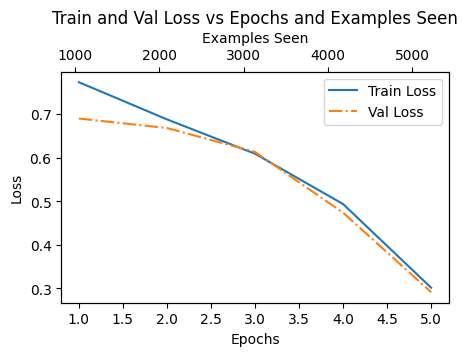

In [70]:
epochs_seen = [1, 2, 3, 4, 5]
plot_values(epochs_seen, tokens_seen, train_losses, val_losses, label='Loss')

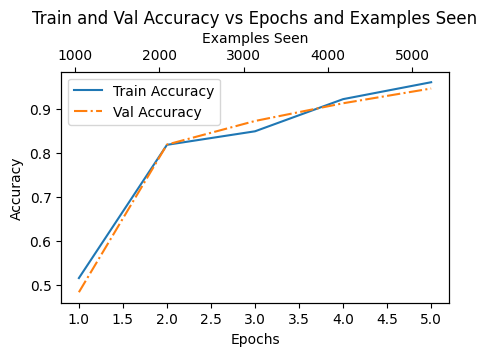

In [71]:
plot_values(epochs_seen, tokens_seen, train_accs, val_accs, label='Accuracy')

## 分类函数

In [78]:
def email_classifier(model, text, tokenizer, device,max_length):
    idx = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    idx = idx[:max_length]
    idx = idx + [50256] * (max_length - len(idx))
    idx = torch.tensor(idx, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(idx)[:, -1, :]
        prediction = torch.argmax(output, dim=-1).item()
    return prediction

In [79]:
spam1 = """
Subject: Urgent! Claim Your Prize Now!!!
Dear Friend,
You have won $1,000,000! Click here to claim: bit.ly/scam-link
Send your bank info now!
Best,
Nigerian Prince
"""
re1 = email_classifier(gpt1, spam1, tokenizer, device,max_length)
print(f"Prediction for spam email: {'Spam' if re1 == 1 else 'Ham'}")

Prediction for spam email: Spam


In [81]:
spam2 = """
Subject: Invoice #2847 Confirmation
Hi,
Your payment receipt is attached. Please review and confirm.
Download: bit.ly/inv-2847
Thanks,
Accounting Team
"""

re2 = email_classifier(gpt1, spam2, tokenizer, device,max_length)
print(f"Prediction for ham email: {'Spam' if re2 == 1 else 'Ham'}")

Prediction for ham email: Spam


In [84]:
ham1 = """
Subject: Charity Raffle This Weekend
Hi Everyone, we're hosting a charity raffle this weekend to raise funds for the local shelter. 
Hope to see you there!
Sarah
"""
re3 = email_classifier(gpt1, ham1, tokenizer, device,max_length)
print(f"Prediction for ham email: {'Spam' if re3 == 1 else 'Ham'}")

Prediction for ham email: Ham
